   match_id team opponent  runs  wickets winner player_of_match
0         1  CSK       MI   180        5    CSK           Dhoni
1         2   MI      RCB   170        6     MI           Rohit
2         3  RCB      CSK   160        7    CSK           Kohli
3         4  KKR       MI   150        8     MI           Rohit
4         5  CSK      RCB   200        4    CSK           Dhoni
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   match_id         12 non-null     int64 
 1   team             12 non-null     object
 2   opponent         12 non-null     object
 3   runs             12 non-null     int64 
 4   wickets          12 non-null     int64 
 5   winner           12 non-null     object
 6   player_of_match  12 non-null     object
dtypes: int64(3), object(4)
memory usage: 804.0+ bytes
None
match_id           0
team               0
opponen

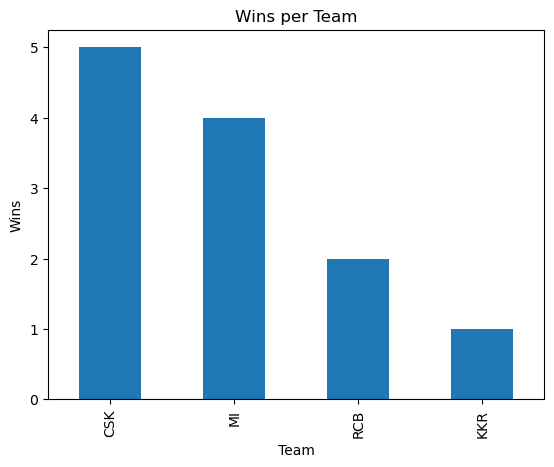

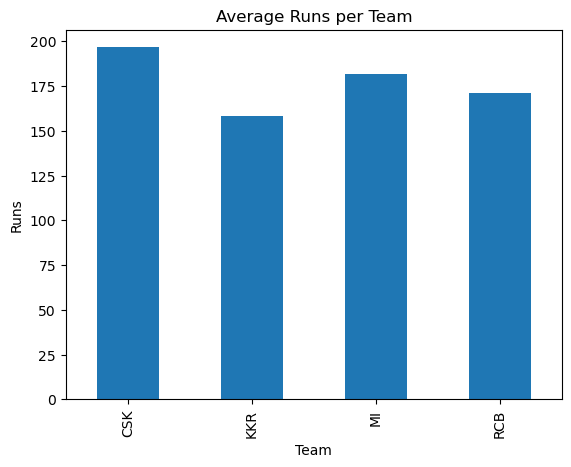

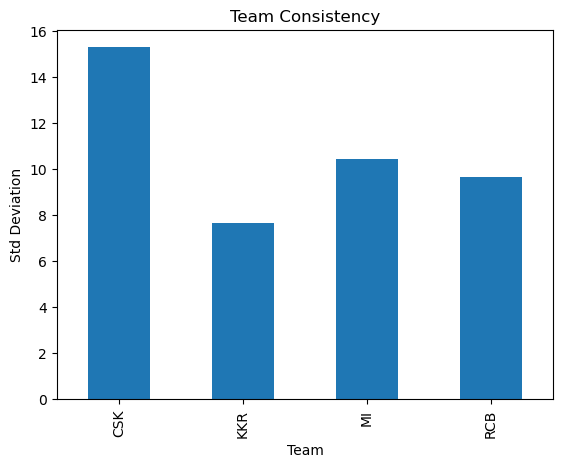

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ipl_data.csv')

print(df.head())
print(df.info())
# Check missing values
print(df.isnull().sum())

# Fill missing runs (if any)
df['runs'] = df['runs'].fillna(df['runs'].mean())
# Best team win percentage
matches_played = df['team'].value_counts()
matches_won = df['winner'].value_counts()

win_percentage = (matches_won / matches_played) * 100
win_percentage = win_percentage.fillna(0)

best_team = win_percentage.idxmax()

print("\nBest Team:", best_team)
print("Win %:", win_percentage.max())
# Top 3 teams win
top3_teams = matches_won.head(3)
print("\nTop 3 Teams:\n", top3_teams)
# highest average runs team
team_avg_runs = df.groupby('team')['runs'].mean()

print("\nTop Scoring Team:", team_avg_runs.idxmax())
print("Average Runs:", team_avg_runs.max())
# most consistency team
consistency = df.groupby('team')['runs'].std()

print("\nMost Consistent Team:", consistency.idxmin())
print("Std Dev:", consistency.min())
# high score (>150)
high_score_df = df[df['runs'] > 150]

high_score_wins = high_score_df['winner'].value_counts()

print("\nBest High Score Team:", high_score_wins.idxmax())
# visualization win per team
matches_won.plot(kind='bar')
plt.title("Wins per Team")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()
# Average runs per team
team_avg_runs.plot(kind='bar')
plt.title("Average Runs per Team")
plt.xlabel("Team")
plt.ylabel("Runs")
plt.show()
# consistency
consistency.plot(kind='bar')
plt.title("Team Consistency")
plt.xlabel("Team")
plt.ylabel("Std Deviation")
plt.show()